# 01 — Data Audit & EDA
Seattle Airbnb Price Prediction — CSE437

This notebook covers report sections **2.1 (data quality audit)** and **3 (statistical analysis)**.
It only *inspects* the raw data — no cleaning happens here, so we can see exactly what the
data looks like before any changes.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../src')

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import parse_price

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


## Load raw data
Place our CSV in `../data/raw/` before running this cell.

In [2]:
csv_candidates = glob.glob('../data/raw/*.csv')
print("Found in data/raw/:", csv_candidates)
assert csv_candidates, "No CSV found in data/raw/ - place the dataset there first."

DATA_PATH = max(csv_candidates, key=lambda p: __import__('os').path.getsize(p))
print("Using:", DATA_PATH)

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df_raw.shape)
df_raw.head()


Found in data/raw/: ['../data/raw\\seattle_01.csv']
Using: ../data/raw\seattle_01.csv
Shape: (7576, 18)


,Unnamed: 0,room_id,host_id,room_type,address,reviews,overall_satisfaction,accommodates,bedrooms,bathrooms,price,last_modified,latitude,longitude,location,name,currency,rate_type
0,0,2318,2536,Entire home/apt,"Seattle, WA, United States",21,5.0,8,4.0,2.5,250,2018-12-20 03:46:14.698548,47.610819,-122.290816,0101000020E6100000D449B6BA9C925EC0416326512FCE...,"Casa Madrona - Urban Oasis, 1 block from the P...",USD,nightly
1,1,3335,4193,Entire home/apt,"Seattle, WA, United States",1,NaN,4,2.0,1.0,100,2018-12-20 04:08:45.277643,47.529846,-122.275840,0101000020E61000006FBBD05CA7915EC04DF564FED1C3...,Sweet Seattle Urban Homestead 2 Bdr,USD,nightly
2,2,4291,35749,Private room,"Seattle, WA, United States",63,4.5,2,1.0,1.0,82,2018-12-20 03:04:19.861014,47.687801,-122.313427,0101000020E6100000BDAB1E300F945EC0FB93F8DC09D8...,Sunrise in Seattle Master Suite,USD,nightly
3,3,5682,8993,Entire home/apt,"Seattle, WA, United States",462,5.0,2,0.0,1.0,49,2018-12-20 04:11:25.482975,47.523980,-122.359891,0101000020E6100000FCC7427408975EC009E1D1C611C3...,"Cozy Studio, min. to downtown -WiFi",USD,nightly
4,4,6606,14942,Entire home/apt,"Seattle, WA, United States",134,4.5,2,1.0,1.0,90,2018-12-20 03:12:38.391711,47.654109,-122.337605,0101000020E6100000D47D00529B955EC07782FDD7B9D3...,"Fab, private seattle urban cottage!",USD,nightly


## 2.1 Data quality audit

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 7576 entries, 0 to 7575
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            7576 non-null   int64  
 1   room_id               7576 non-null   int64  
 2   host_id               7576 non-null   int64  
 3   room_type             7576 non-null   str    
 4   address               7576 non-null   str    
 5   reviews               7576 non-null   int64  
 6   overall_satisfaction  6103 non-null   float64
 7   accommodates          7576 non-null   int64  
 8   bedrooms              7576 non-null   float64
 9   bathrooms             7574 non-null   float64
 10  price                 7576 non-null   int64  
 11  last_modified         7576 non-null   str    
 12  latitude              7576 non-null   float64
 13  longitude             7576 non-null   float64
 14  location              7576 non-null   str    
 15  name                  7576 non-n

In [ ]:

missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print("Columns with missing values:")
missing_pct[missing_pct > 0]


Columns with missing values:


overall_satisfaction    19.442978
bathrooms                0.026399
dtype: float64

In [ ]:
n_dupes = int(df_raw.duplicated().sum())
print(f"Fully duplicated rows: {n_dupes}")

listing_id_col = 'room_id' if 'room_id' in df_raw.columns else 'id' if 'id' in df_raw.columns else None
if listing_id_col:
    n_dupe_ids = int(df_raw[listing_id_col].duplicated().sum())
    print(f"Duplicate {listing_id_col} values: {n_dupe_ids}")
else:
    print("No listing identifier column found.")

Fully duplicated rows: 0
Duplicate room_id values: 0


In [ ]:
for col in ['room_type', 'property_type', 'host_is_superhost']:
    if col in df_raw.columns:
        print(f"\n{col} value counts:")
        print(df_raw[col].value_counts(dropna=False))



room_type value counts:
room_type
Entire home/apt    5603
Private room       1844
Shared room         129
Name: count, dtype: int64


In [ ]:
if 'price' in df_raw.columns:
    price_preview = parse_price(df_raw['price'])
    print(price_preview.describe())
    print(f"\nListings priced at $0 or missing: {(price_preview.fillna(0) <= 0).sum()}")

for col in ['minimum_nights', 'availability_365', 'bedrooms', 'bathrooms']:
    if col in df_raw.columns:
        print(f"\n{col} min/max:", df_raw[col].min(), df_raw[col].max())


count    7576.000000
mean      113.024419
std       122.481780
min        15.000000
25%        65.000000
50%        88.000000
75%       125.000000
max      5900.000000
Name: price, dtype: float64

Listings priced at $0 or missing: 0

bedrooms min/max: 0.0 8.0

bathrooms min/max: 0.0 8.0


## 3.1 Descriptive statistics (raw, pre-cleaning)

In [8]:
numeric_preview = df_raw.select_dtypes(include=[np.number])
numeric_preview.describe().T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,7576.0,3.973629e+03,2.297418e+03,0.000000,1.981750e+03,3.970500e+03,5.945250e+03,7.974000e+03
room_id,7576.0,1.778928e+07,8.739765e+06,2318.000000,1.121214e+07,1.960824e+07,2.484480e+07,3.099842e+07
host_id,7576.0,5.245040e+07,5.955274e+07,2536.000000,8.315334e+06,2.696758e+07,8.073960e+07,2.314354e+08
reviews,7576.0,4.765800e+01,6.588933e+01,0.000000,4.000000e+00,2.100000e+01,6.400000e+01,6.870000e+02
overall_satisfaction,6103.0,4.841226e+00,2.816779e-01,2.500000,4.500000e+00,5.000000e+00,5.000000e+00,5.000000e+00
accommodates,7576.0,3.682946e+00,2.332280e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,2.800000e+01
bedrooms,7576.0,1.385428e+00,1.009823e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00
bathrooms,7574.0,1.307367e+00,6.410357e-01,0.000000,1.000000e+00,1.000000e+00,1.500000e+00,8.000000e+00
price,7576.0,1.130244e+02,1.224818e+02,15.000000,6.500000e+01,8.800000e+01,1.250000e+02,5.900000e+03
latitude,7576.0,4.762435e+01,4.627024e-02,47.508078,4.760423e+01,4.762004e+01,4.765975e+01,4.772305e+01


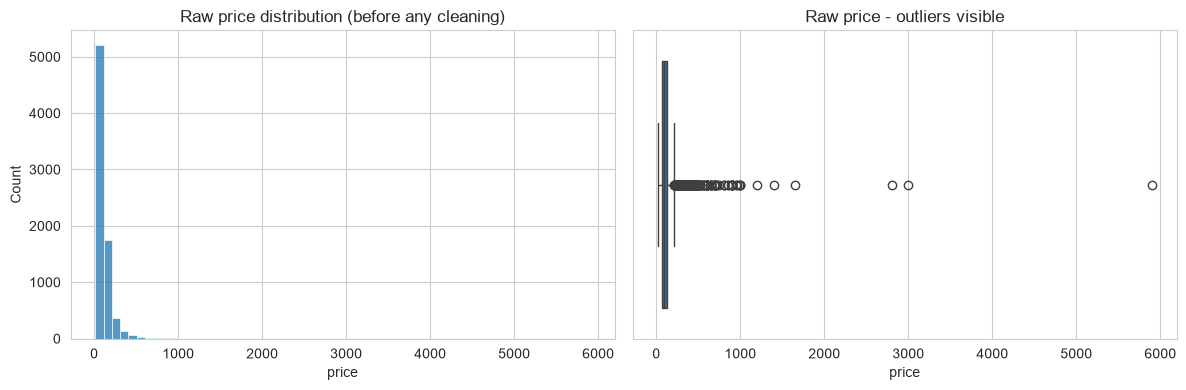

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(price_preview.dropna(), bins=60, ax=axes[0])
axes[0].set_title('Raw price distribution (before any cleaning)')
sns.boxplot(x=price_preview.dropna(), ax=axes[1])
axes[1].set_title('Raw price - outliers visible')
plt.tight_layout()
plt.savefig('../figures/01_raw_price_distribution.png', dpi=120)
plt.show()


## 3.3 What the data says so far

- The supplied file contains 7,576 listings and 18 columns, including an unnamed CSV index that should be removed during preprocessing.
- `overall_satisfaction` is missing for 1,473 listings (19.44%); `bathrooms` has only a small amount of missingness (0.026%).
- There are no fully duplicated rows and no duplicated `room_id` values.
- The data is imbalanced toward entire-home listings: 5,603 entire homes, 1,844 private rooms, and 129 shared rooms.
- Prices are positive but highly right-skewed: the median is `$88`, the mean is `$113.02`, and the maximum is `$5,900`. This supports capping extreme values and modeling `log_price`.